# Cross-chain master vault CCTP backtest

Backtest notebook for the Ethereum primary-chain vault-of-vaults strategy with Base and Arbitrum satellite vaults. The notebook uses real vault history and generated CCTP bridge pairs, then asserts that CCTP trades are generated and the run finishes profitably.


## Notebook setup

Set up the Trading Strategy client, chart output, and imports used throughout the notebook.


In [1]:
import datetime
import logging
import os

import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import display
from dotenv import load_dotenv
from eth_defi.token import USDC_NATIVE_TOKEN
from plotly.graph_objects import Figure
from tradingstrategy.chain import ChainId
from tradingstrategy.client import Client
from tradingstrategy.timebucket import TimeBucket
from tradingstrategy.utils.token_filter import filter_for_selected_pairs

from tradeexecutor.backtest.backtest_runner import run_backtest_inline
from tradeexecutor.curator import is_quarantined
from tradeexecutor.ethereum.vault.checks import check_stale_vault_data
from tradeexecutor.exchange_account.allocation import (
    calculate_portfolio_target_value,
    get_redeemable_portfolio_capital,
)
from tradeexecutor.state.identifier import TradingPairIdentifier
from tradeexecutor.state.trade import TradeExecution
from tradeexecutor.state.types import USDollarAmount
from tradeexecutor.strategy.alpha_model import AlphaModel
from tradeexecutor.strategy.chart.definition import ChartInput, ChartKind, ChartRegistry
from tradeexecutor.strategy.chart.standard.alpha_model import (
    alpha_model_diagnostics,
    missed_vault_deposit_redemption_events,
    missed_vault_deposit_redemption_timeline,
)
from tradeexecutor.strategy.chart.standard.equity_curve import (
    equity_curve as equity_curve_chart,
    equity_curve_with_drawdown,
)
from tradeexecutor.strategy.chart.standard.interest import vault_statistics
from tradeexecutor.strategy.chart.standard.performance_metrics import performance_metrics
from tradeexecutor.strategy.chart.standard.position import positions_at_end
from tradeexecutor.strategy.chart.standard.profit_breakdown import trading_pair_breakdown
from tradeexecutor.strategy.chart.standard.thinking import last_messages
from tradeexecutor.strategy.chart.standard.trading_metrics import trading_metrics
from tradeexecutor.strategy.chart.standard.trading_universe import (
    available_trading_pairs,
    inclusion_criteria_check,
)
from tradeexecutor.strategy.chart.standard.vault import all_vault_positions
from tradeexecutor.strategy.chart.standard.weight import (
    equity_curve_by_asset,
    equity_curve_by_chain,
    weight_allocation_statistics,
)
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.strategy.default_routing_options import TradeRouting
from tradeexecutor.strategy.execution_context import ExecutionContext, ExecutionMode, notebook_execution_context
from tradeexecutor.strategy.pandas_trader.indicator import (
    IndicatorDependencyResolver,
    IndicatorSource,
)
from tradeexecutor.strategy.pandas_trader.indicator_decorator import IndicatorRegistry
from tradeexecutor.strategy.pandas_trader.strategy_input import StrategyInput
from tradeexecutor.strategy.pandas_trader.trading_universe_input import CreateTradingUniverseInput
from tradeexecutor.strategy.parameters import StrategyParameters
from tradeexecutor.strategy.reserve_currency import ReserveCurrency
from tradeexecutor.strategy.tag import StrategyTag
from tradeexecutor.strategy.trading_strategy_universe import (
    TradingStrategyUniverse,
    load_partial_data,
    load_vault_universe_with_metadata,
)
from tradeexecutor.strategy.tvl_size_risk import USDTVLSizeRiskModel
from tradeexecutor.strategy.universe_model import UniverseOptions
from tradeexecutor.strategy.weighting import weight_passthrouh
from tradeexecutor.utils.dedent import dedent_any
from tradeexecutor.utils.notebook import OutputMode, display_head_and_tail, setup_charting_and_output
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns

load_dotenv(override=True)
setup_charting_and_output(OutputMode.static, image_format="png", width=1500, height=900)

api_key = os.environ.get("TRADING_STRATEGY_API_KEY")
client = Client.create_jupyter_client(api_key=api_key)
logger = logging.getLogger("strategy")

trading_strategy_engine_version = "0.5"

Started Trading Strategy in Jupyter notebook environment, configuration is stored in /Users/moo/.tradingstrategy


## Universe definition

Native-USDC vaults on Ethereum, Base, and Arbitrum with CCTP bridge pairs for cross-chain allocation.

In [2]:
LENDING_RESERVES = None

SUPPORTING_PAIRS = [
    (ChainId.ethereum, "uniswap-v3", "WETH", "USDC", 0.0005),
    (ChainId.ethereum, "uniswap-v3", "WBTC", "USDC", 0.003),
    (ChainId.arbitrum, "uniswap-v3", "WETH", "USDC", 0.0005),
    (ChainId.base, "uniswap-v3", "WETH", "USDC", 0.0005),
]

SOURCE_VAULTS = [
    # Ethereum native-USDC vaults
    (ChainId.ethereum, "0x09c4c7b1d2e9aa7506db8b76f1dbbd61c08c114b"),
    (ChainId.ethereum, "0x438982ea288763370946625fd76c2508ee1fb229"),
    (ChainId.ethereum, "0x8df3deba711ae4a9af16cbca5e4fbb1402f036d5"),
    (ChainId.ethereum, "0xca790385506b790554571cbc9da73f0130cdcfd5"),
    (ChainId.ethereum, "0xe9d33286f0e37f517b1204aa6da085564414996d"),
    # Base native-USDC vaults
    (ChainId.base, "0xf7e26fa48a568b8b0038e104dfd8abdf0f99074f"),
    (ChainId.base, "0x3094b241aade60f91f1c82b0628a10d9501462f9"),
    (ChainId.base, "0x70fffbacb53ef74903ac074aae769414a70970d1"),
    (ChainId.base, "0x3ec4a293fb906dd2cd440c20decb250def141df1"),
    (ChainId.base, "0x8092ca384d44260ea4feaf7457b629b8dc6f88f0"),
    (ChainId.base, "0xc777031d50f632083be7080e51e390709062263e"),
    (ChainId.base, "0xad20523a7dc37babc1cc74897e4977232b3d02e5"),
    (ChainId.base, "0xbc10718571fcb3c3f67800e7c0887e450d2ff398"),
    (ChainId.base, "0xefe32813dba3a783059d50e5358b9e3661218dad"),
    (ChainId.base, "0xd5c22fa3f7ee979ed7c28e36669b29797ab277e4"),
    # Arbitrum native-USDC vaults
    (ChainId.arbitrum, "0x75288264fdfea8ce68e6d852696ab1ce2f3e5004"),
    (ChainId.arbitrum, "0x58bfc95a864e18e8f3041d2fcd3418f48393fe6a"),
    (ChainId.arbitrum, "0xf63b7f49b4f5dc5d0e7e583cfd79dc64e646320c"),
    (ChainId.arbitrum, "0x1723cb57af58efb35a013870c90fcc3d60174a4e"),
    (ChainId.arbitrum, "0x20d419a8e12c45f88fda7c5760bb6923cee27f98"),
    (ChainId.arbitrum, "0xd3443ee1e91af28e5fb858fbd0d72a63ba8046e0"),
    (ChainId.arbitrum, "0x0df2e3a0b5997adc69f8768e495fd98a4d00f134"),
]

BENCHMARK_PAIRS = SUPPORTING_PAIRS

## Parameters

Cross-chain CCTP backtest with age-ramp weighting, vol-of-vol veto, and daily rebalancing.

In [ ]:
class Parameters:
    id = "xchain-master-vault-eth-arb-base-cctp-notebook"
    candle_time_bucket = TimeBucket.h4
    cycle_duration = CycleDuration.cycle_8h
    chain_id = ChainId.cross_chain
    primary_chain_id = ChainId.ethereum
    supporting_pairs = SUPPORTING_PAIRS
    source_vaults = SOURCE_VAULTS
    preferred_stablecoin = USDC_NATIVE_TOKEN[ChainId.ethereum].lower()
    auto_generate_cctp_bridges = True

    backtest_start = datetime.datetime(2025, 1, 1)
    backtest_end = datetime.datetime(2026, 3, 11)
    initial_cash = 100_000

    max_assets_in_portfolio = 12
    allocation_pct = 0.98
    max_concentration_pct = 0.12
    per_position_cap_of_pool_pct = 0.2
    min_portfolio_weight_pct = 0.005

    absolute_min_vault_deposit_usd = 5.0
    individual_rebalance_min_threshold_usd = 50.0
    sell_rebalance_min_threshold_usd = 10.0

    min_tvl_usd = 7_500
    min_age = 0.075
    weight_signal = "age_ramp"
    age_ramp_period = 0.75

    vol_window = 60
    volvol_veto_percentile = 0.75

    required_history_period = datetime.timedelta(days=365)
    routing = TradeRouting.default
    slippage_tolerance_pct = 0.0060
    assummed_liquidity_when_data_missings_usd = 0.01


parameters = StrategyParameters.from_class(Parameters)

## Trading universe builder

Load vault metadata, filter to native USDC when CCTP is active, and build the cross-chain dataset.

In [4]:
def _get_available_supporting_pair_ids(strategy_universe):
    pair_ids = set()
    for desc in SUPPORTING_PAIRS:
        try:
            pair_ids.add(strategy_universe.get_pair_by_human_description(desc).internal_id)
        except KeyError:
            continue
    return pair_ids


def create_trading_universe(input: CreateTradingUniverseInput) -> TradingStrategyUniverse:
    execution_context = input.execution_context
    client = input.client
    timestamp = input.timestamp
    params = input.parameters or Parameters
    universe_options = input.universe_options

    debug_printer = logger.info if execution_context.live_trading else print
    chain_id = params.primary_chain_id

    supporting_pairs = [] if execution_context.live_trading else params.supporting_pairs

    debug_printer(f"Preparing trading universe on chain {chain_id.get_name()}")

    all_pairs_df = client.fetch_pair_universe().to_pandas()
    pairs_df = filter_for_selected_pairs(all_pairs_df, supporting_pairs)
    debug_printer(f"We have total {len(all_pairs_df)} pairs in dataset and going to use {len(pairs_df)} pairs for the strategy")

    vault_universe = load_vault_universe_with_metadata(client, vaults=params.source_vaults)
    if params.auto_generate_cctp_bridges:
        vault_universe = vault_universe.limit_to_native_usdc()
    debug_printer(
        f"Loaded {vault_universe.get_vault_count()} vaults from remote vault metadata, "
        f"source vaults count: {len(params.source_vaults)}"
    )

    dataset = load_partial_data(
        client=client,
        time_bucket=params.candle_time_bucket,
        pairs=pairs_df,
        execution_context=execution_context,
        universe_options=universe_options,
        liquidity=True,
        liquidity_time_bucket=TimeBucket.d1,
        lending_reserves=LENDING_RESERVES,
        vaults=vault_universe,
        vault_history_source="trading-strategy-website",
        check_all_vaults_found=True,
    )

    return TradingStrategyUniverse.create_from_dataset(
        dataset,
        reserve_asset=params.preferred_stablecoin,
        forward_fill=True,
        forward_fill_until=timestamp,
        primary_chain=params.primary_chain_id,
        auto_generate_cctp_bridges=params.auto_generate_cctp_bridges,
    )

## Indicators

TVL, age, inclusion criteria, age-ramp weighting, and vol-of-vol veto indicators.

In [5]:
indicators = IndicatorRegistry()


@indicators.define(source=IndicatorSource.tvl)
def tvl(close: pd.Series) -> pd.Series:
    return close


@indicators.define()
def age(close: pd.Series) -> pd.Series:
    inception = close.index[0]
    age_years = (close.index - inception) / pd.Timedelta(days=365.25)
    return pd.Series(age_years, index=close.index)


@indicators.define(dependencies=(tvl,), source=IndicatorSource.dependencies_only_universe)
def tvl_inclusion_criteria(min_tvl_usd: USDollarAmount, dependency_resolver: IndicatorDependencyResolver) -> pd.Series:
    series = dependency_resolver.get_indicator_data_pairs_combined(tvl)
    mask = series >= min_tvl_usd
    mask_true_values_only = mask[mask]
    return mask_true_values_only.groupby(level="timestamp").apply(
        lambda x: x.index.get_level_values("pair_id").tolist()
    )


@indicators.define(dependencies=(age,), source=IndicatorSource.dependencies_only_universe)
def age_inclusion_criteria(min_age: float, dependency_resolver: IndicatorDependencyResolver) -> pd.Series:
    series = dependency_resolver.get_indicator_data_pairs_combined(age)
    mask = series >= min_age
    mask_true_values_only = mask[mask]
    return mask_true_values_only.groupby(level="timestamp").apply(
        lambda x: x.index.get_level_values("pair_id").tolist()
    )


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_availability_criteria(strategy_universe: TradingStrategyUniverse) -> pd.Series:
    candle_series = strategy_universe.data_universe.candles.df["open"]
    return candle_series.groupby(level="timestamp").apply(
        lambda x: x.index.get_level_values("pair_id").tolist()
    )


@indicators.define(
    dependencies=[tvl_inclusion_criteria, trading_availability_criteria, age_inclusion_criteria],
    source=IndicatorSource.strategy_universe,
)
def inclusion_criteria(
    strategy_universe: TradingStrategyUniverse,
    min_tvl_usd: USDollarAmount,
    min_age: float,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    benchmark_pair_ids = _get_available_supporting_pair_ids(strategy_universe)
    tvl_series = dependency_resolver.get_indicator_data(tvl_inclusion_criteria, parameters={"min_tvl_usd": min_tvl_usd})
    trading_availability_series = dependency_resolver.get_indicator_data(trading_availability_criteria)
    age_series = dependency_resolver.get_indicator_data(age_inclusion_criteria, parameters={"min_age": min_age})

    df = pd.DataFrame({"tvl_pair_ids": tvl_series, "trading_availability_pair_ids": trading_availability_series, "age_pair_ids": age_series})
    df = df.fillna("").apply(list)

    def _combine(row):
        return set(row["tvl_pair_ids"]) & set(row["trading_availability_pair_ids"]) & set(row["age_pair_ids"]) - benchmark_pair_ids

    union_criteria = df.apply(_combine, axis=1)
    full_index = pd.date_range(start=union_criteria.index.min(), end=union_criteria.index.max(), freq=Parameters.candle_time_bucket.to_frequency())
    return union_criteria.reindex(full_index, fill_value=[])


@indicators.define(dependencies=(age,), source=IndicatorSource.dependencies_only_per_pair)
def age_ramp_weight(pair: TradingPairIdentifier, dependency_resolver: IndicatorDependencyResolver, age_ramp_period: float = 1.0) -> pd.Series:
    vault_age = dependency_resolver.get_indicator_data("age", pair=pair)
    return (vault_age / age_ramp_period).clip(upper=1.0).clip(lower=0.05)


@indicators.define()
def realised_vol(close: pd.Series, vol_window: int = 60) -> pd.Series:
    daily_returns = close.pct_change().fillna(0)
    rolling_std = daily_returns.rolling(window=vol_window, min_periods=7).std()
    return rolling_std * (365 ** 0.5)


@indicators.define(dependencies=(realised_vol,), source=IndicatorSource.dependencies_only_per_pair)
def vol_of_vol(pair: TradingPairIdentifier, dependency_resolver: IndicatorDependencyResolver, vol_window: int = 60) -> pd.Series:
    realised_vol_series = dependency_resolver.get_indicator_data("realised_vol", pair=pair, parameters={"vol_window": vol_window})
    return realised_vol_series.rolling(window=vol_window, min_periods=7).std()


@indicators.define(dependencies=(inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def all_criteria_included_pair_count(min_tvl_usd: USDollarAmount, min_age: float, dependency_resolver: IndicatorDependencyResolver) -> pd.Series:
    series = dependency_resolver.get_indicator_data("inclusion_criteria", parameters={"min_tvl_usd": min_tvl_usd, "min_age": min_age})
    return series.apply(len)


@indicators.define(dependencies=(tvl_inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def tvl_included_pair_count(min_tvl_usd: USDollarAmount, dependency_resolver: IndicatorDependencyResolver) -> pd.Series:
    series = dependency_resolver.get_indicator_data("tvl_inclusion_criteria", parameters={"min_tvl_usd": min_tvl_usd})
    return series.apply(len)


@indicators.define(dependencies=(age_inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def age_included_pair_count(min_age: float, dependency_resolver: IndicatorDependencyResolver) -> pd.Series:
    series = dependency_resolver.get_indicator_data("age_inclusion_criteria", parameters={"min_age": min_age})
    return series.apply(len)


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_pair_count(strategy_universe: TradingStrategyUniverse) -> pd.Series:
    benchmark_pair_ids = _get_available_supporting_pair_ids(strategy_universe)
    series = strategy_universe.data_universe.candles.df["open"]
    swap_index = series.index.swaplevel(0, 1)
    seen_pairs = set()
    seen_data = {}
    for timestamp, pair_id in swap_index:
        if pair_id in benchmark_pair_ids:
            continue
        seen_pairs.add(pair_id)
        seen_data[timestamp] = len(seen_pairs)
    return pd.Series(seen_data.values(), index=list(seen_data.keys()))


def create_indicators(timestamp, parameters, strategy_universe, execution_context):
    return indicators.create_indicators(
        timestamp=timestamp, parameters=parameters,
        strategy_universe=strategy_universe, execution_context=execution_context,
    )

## Strategy logic

Survivor-first capped waterfall sizing with age-ramp weighting, vol-of-vol veto, and redemption-aware target value.

In [6]:
def decide_trades(input: StrategyInput) -> list[TradeExecution]:
    parameters = input.parameters
    position_manager = input.get_position_manager()
    state = input.state
    timestamp = input.timestamp
    indicators = input.indicators
    strategy_universe = input.strategy_universe

    check_stale_vault_data(strategy_universe, timestamp, input.execution_context.mode)

    portfolio = position_manager.get_current_portfolio()
    equity = portfolio.get_total_equity()

    if input.execution_context.mode == ExecutionMode.backtesting and equity < parameters.initial_cash * 0.10:
        return []

    alpha_model = AlphaModel(timestamp, close_position_weight_epsilon=parameters.min_portfolio_weight_pct)

    tvl_included_pair_count = indicators.get_indicator_value("tvl_included_pair_count")
    included_pairs = indicators.get_indicator_value("inclusion_criteria", na_conversion=False)
    if included_pairs is None:
        included_pairs = []

    volvol_values = {}
    for pair_id in included_pairs:
        pair = strategy_universe.get_pair_by_id(pair_id)
        vol_of_vol_value = indicators.get_indicator_value("vol_of_vol", pair=pair)
        if vol_of_vol_value is not None and not pd.isna(vol_of_vol_value):
            volvol_values[pair_id] = vol_of_vol_value

    volvol_threshold = np.percentile(list(volvol_values.values()), parameters.volvol_veto_percentile * 100) if volvol_values else float("inf")

    vetoed_count = 0
    signal_count = 0
    for pair_id in included_pairs:
        pair = strategy_universe.get_pair_by_id(pair_id)
        if not state.is_good_pair(pair):
            continue
        if is_quarantined(pair.pool_address, timestamp):
            continue
        vol_of_vol_value = volvol_values.get(pair_id)
        if vol_of_vol_value is not None and vol_of_vol_value > volvol_threshold:
            vetoed_count += 1
            continue
        age_ramp_weight_value = indicators.get_indicator_value("age_ramp_weight", pair=pair)
        weight_signal_value = age_ramp_weight_value if age_ramp_weight_value is not None else 1.0
        alpha_model.set_signal(pair, weight_signal_value)
        signal_count += 1

    locked_position_value = alpha_model.carry_forward_non_redeemable_positions(position_manager)
    redeemable_capital = get_redeemable_portfolio_capital(position_manager)
    portfolio_target_value = calculate_portfolio_target_value(position_manager, parameters.allocation_pct)
    deployable_target_value = max(portfolio_target_value - locked_position_value, 0.0)

    alpha_model.select_top_signals(count=parameters.max_assets_in_portfolio)
    alpha_model.assign_weights(method=weight_passthrouh)

    size_risk_model = USDTVLSizeRiskModel(
        pricing_model=input.pricing_model,
        per_position_cap=parameters.per_position_cap_of_pool_pct,
    )

    alpha_model.normalise_weights(
        investable_equity=deployable_target_value,
        size_risk_model=size_risk_model,
        max_weight=parameters.max_concentration_pct,
        max_positions=parameters.max_assets_in_portfolio,
        waterfall=True,
    )
    alpha_model.update_old_weights(state.portfolio, ignore_credit=False)
    alpha_model.calculate_target_positions(position_manager)

    trades = alpha_model.generate_rebalance_trades_and_triggers(
        position_manager,
        min_trade_threshold=parameters.individual_rebalance_min_threshold_usd,
        individual_rebalance_min_threshold=parameters.individual_rebalance_min_threshold_usd,
        sell_rebalance_min_threshold=parameters.sell_rebalance_min_threshold_usd,
        execution_context=input.execution_context,
    )
    missed_vault_events = alpha_model.get_missed_vault_events()
    if missed_vault_events:
        state.visualisation.add_calculations(timestamp, {"missed_vault_events": missed_vault_events})

    if input.is_visualisation_enabled():
        try:
            top_signal = next(iter(alpha_model.get_signals_sorted_by_weight()))
            if top_signal.normalised_weight == 0:
                top_signal = None
        except StopIteration:
            top_signal = None

        rebalance_volume = sum(trade.get_value() for trade in trades)
        report = dedent_any(f"""
            Cycle: #{input.cycle}
            Rebalanced: {'yes' if alpha_model.is_rebalance_triggered() else 'no'}
            Open/about to open positions: {len(state.portfolio.open_positions)}
            Trades decided: {len(trades)}
            Pairs meeting inclusion criteria: {len(included_pairs)}
            Vol-of-vol threshold: {volvol_threshold:.6f}
            Vaults vetoed by vol-of-vol: {vetoed_count}
            Candidate signals: {signal_count}
            Total equity: {portfolio.get_total_equity():,.2f} USD
            Cash: {position_manager.get_current_cash():,.2f} USD
            Rebalance volume: {rebalance_volume:,.2f} USD
        """)

        if top_signal:
            report += dedent_any(f"""
                Top signal: {top_signal.pair.get_ticker()} weight={top_signal.normalised_weight * 100:.2f}%
            """)

        state.visualisation.add_message(timestamp, report)
        state.visualisation.set_discardable_data("alpha_model", alpha_model)

    return trades

## Charts

Standard chart registry with cross-chain extensions.

In [7]:
from tradeexecutor.strategy.chart.standard.cycle_snapshot import latest_cycle_snapshot


def equity_curve_with_benchmark(input: ChartInput) -> list[Figure]:
    """Equity curve with ETH benchmark."""
    return equity_curve_chart(input, benchmark_token_symbols=["ETH"])


def inclusion_criteria_check_with_chain(input: ChartInput) -> pd.DataFrame:
    """Inclusion criteria table with chain shown."""
    return inclusion_criteria_check(input, show_chain=True)


def trading_pair_breakdown_with_chain(input: ChartInput) -> pd.DataFrame:
    """Trading pair breakdown with chain and address."""
    return trading_pair_breakdown(input, show_chain=True, show_address=True)


def all_vault_positions_by_profit(input: ChartInput) -> pd.DataFrame:
    """Vault positions sorted by profit."""
    return all_vault_positions(input, sort_by="Profit USD", sort_ascending=False, show_address=True)


def create_charts(timestamp, parameters, strategy_universe, execution_context):
    default_benchmark_pairs = [] if execution_context.live_trading else BENCHMARK_PAIRS
    charts = ChartRegistry(default_benchmark_pairs=default_benchmark_pairs)
    charts.register(available_trading_pairs, ChartKind.indicator_all_pairs)
    charts.register(inclusion_criteria_check_with_chain, ChartKind.indicator_all_pairs)
    charts.register(equity_curve_with_benchmark, ChartKind.state_all_pairs)
    charts.register(equity_curve_with_drawdown, ChartKind.state_all_pairs)
    charts.register(performance_metrics, ChartKind.state_all_pairs)
    charts.register(equity_curve_by_asset, ChartKind.state_all_pairs)
    charts.register(equity_curve_by_chain, ChartKind.state_all_pairs)
    charts.register(weight_allocation_statistics, ChartKind.state_all_pairs)
    charts.register(positions_at_end, ChartKind.state_all_pairs)
    charts.register(last_messages, ChartKind.state_all_pairs)
    charts.register(alpha_model_diagnostics, ChartKind.state_all_pairs)
    charts.register(missed_vault_deposit_redemption_events, ChartKind.state_all_pairs)
    charts.register(missed_vault_deposit_redemption_timeline, ChartKind.state_all_pairs)
    charts.register(trading_pair_breakdown_with_chain, ChartKind.state_all_pairs)
    charts.register(trading_metrics, ChartKind.state_all_pairs)
    charts.register(vault_statistics, ChartKind.state_all_pairs)
    charts.register(all_vault_positions_by_profit, ChartKind.state_all_pairs)
    charts.register(latest_cycle_snapshot, ChartKind.state_all_pairs)
    return charts

## Trading universe

Build the real-data trading universe and check that the synthetic CCTP bridge pairs were generated for both satellite chains.


In [8]:
universe_input = CreateTradingUniverseInput(
    client=client,
    timestamp=None,
    parameters=parameters,
    execution_context=notebook_execution_context,
    execution_model=None,
    universe_options=UniverseOptions.from_strategy_parameters_class(Parameters, notebook_execution_context),
)
strategy_universe = create_trading_universe(universe_input)

pairs = list(strategy_universe.iterate_pairs())
vault_pairs = [pair for pair in pairs if pair.kind.is_vault()]
bridge_pairs = [pair for pair in pairs if pair.kind.is_cctp_bridge()]

universe_summary = pd.DataFrame(
    [
        ("Chains", ", ".join(sorted(chain.get_name() for chain in strategy_universe.data_universe.chains))),
        ("Total pairs", len(pairs)),
        ("Vault pairs", len(vault_pairs)),
        ("CCTP bridge pairs", len(bridge_pairs)),
        ("Vault denominations", ", ".join(sorted({pair.quote.token_symbol for pair in vault_pairs}))),
        ("Bridge destinations", ", ".join(str(pair.get_destination_chain_id()) for pair in bridge_pairs)),
    ],
    columns=["Metric", "Value"],
)

display(universe_summary)

assert {pair.get_destination_chain_id() for pair in bridge_pairs} == {ChainId.arbitrum.value, ChainId.base.value}
assert {pair.quote.token_symbol for pair in vault_pairs} == {"USDC"}
for pair in vault_pairs:
    expected_addr = USDC_NATIVE_TOKEN.get(pair.chain_id)
    assert expected_addr is not None, f"No native USDC address for chain {pair.chain_id}"
    assert pair.quote.address.lower() == expected_addr.lower(), (
        f"{pair.get_ticker()} denomination {pair.quote.address} != native USDC {expected_addr}"
    )

Preparing trading universe on chain Ethereum
We have total 391797 pairs in dataset and going to use 4 pairs for the strategy


Failed to parse vault entry: 4326 is not a valid ChainId
Failed to parse vault entry: 4326 is not a valid ChainId
Failed to parse vault entry: 4326 is not a valid ChainId
Failed to parse vault entry: 9997 is not a valid ChainId
Failed to parse vault entry: 9997 is not a valid ChainId
Failed to parse vault entry: 9997 is not a valid ChainId


Loaded 22 vaults from remote vault metadata, source vaults count: 22


Loading TVL/liquidity data for 4 pairs:   0%|          | 0/4 [00:00<?, ?it/s]

,Metric,Value
0,Chains,"Arbitrum One, Base, Ethereum"
1,Total pairs,28
2,Vault pairs,22
3,CCTP bridge pairs,2
4,Vault denominations,USDC
5,Bridge destinations,"8453, 42161"


## Backtest

Run the production decision logic on the three-chain universe. `max_workers=1` keeps notebook execution deterministic.

In [9]:
result = run_backtest_inline(
    client=client,
    universe=strategy_universe,
    decide_trades=decide_trades,
    create_indicators=create_indicators,
    parameters=Parameters,
    initial_deposit=Parameters.initial_cash,
    reserve_currency=ReserveCurrency.usdc,
    trade_routing=Parameters.routing,
    engine_version=trading_strategy_engine_version,
    max_workers=1,
    name=Parameters.id,
)

state = result.state
indicator_data = result.indicators
trades = list(state.portfolio.get_all_trades())
bridge_trades = [trade for trade in trades if trade.pair.is_cctp_bridge()]
vault_trades = [trade for trade in trades if trade.pair.kind.is_vault()]
equity_curve = calculate_equity_curve(state)
returns = calculate_returns(equity_curve)
final_equity = state.portfolio.get_total_equity()
total_return = final_equity / Parameters.initial_cash - 1

summary_df = pd.DataFrame(
    [
        ("Initial cash USD", Parameters.initial_cash),
        ("Final equity USD", final_equity),
        ("Total return", total_return),
        ("Equity curve points", len(equity_curve)),
        ("All trades", len(trades)),
        ("Vault trades", len(vault_trades)),
        ("CCTP bridge trades", len(bridge_trades)),
        ("Successful CCTP bridge trades", sum(trade.is_success() for trade in bridge_trades)),
    ],
    columns=["Metric", "Value"],
)

display(summary_df)

assert final_equity > Parameters.initial_cash, f"Expected profitable run, got final equity {final_equity:,.2f}"
assert len(bridge_trades) > 0, "Expected CCTP bridge trades to be generated"
assert all(trade.is_success() for trade in bridge_trades), "Expected all CCTP bridge trades to execute"

Reading cached indicators tvl, age, tvl_inclusion_criteria, age_inclusion_criteria, trading_availability_crite…

Using indicator cache /Users/moo/.cache/indicators/arbitrum-base-ethereum_1d_28p0d7d8b9a_2024-01-02-2026-03-11_ff_cross


  0%|          | 0/37497600 [00:00<?, ?it/s]

,Metric,Value
0,Initial cash USD,100000.000000
1,Final equity USD,115232.856485
2,Total return,0.152329
3,Equity curve points,434.000000
4,All trades,588.000000
5,Vault trades,392.000000
6,CCTP bridge trades,196.000000
7,Successful CCTP bridge trades,196.000000


## CCTP trade diagnostics

Inspect bridge direction, destination chain, size, and status. These diagnostics are CCTP-specific and guard against silent bridge-planner regressions.


In [10]:
from tradeexecutor.analysis.cctp import build_bridge_trade_dataframe, build_bridge_trade_summary

bridge_df = build_bridge_trade_dataframe(bridge_trades)
display_head_and_tail(bridge_df, head_rows=10, tail_rows=10)

bridge_summary_df = build_bridge_trade_summary(bridge_df)
display(bridge_summary_df)

assert set(bridge_df["destination_chain_id"]) == {ChainId.arbitrum.value, ChainId.base.value}
assert {"bridge out", "bridge back"}.issubset(set(bridge_df["direction"])), "Expected both bridge directions"
assert bridge_df["value_usd"].sum() > 0

Head (10 rows)


,trade_id,opened_at,executed_at,direction,source_chain_id,destination_chain_id,value_usd,quantity,status,position_id
11,8,2025-01-01,2025-01-01,bridge out,1,8453,47040.000000,47040.000000,success,8
9,9,2025-01-01,2025-01-01,bridge out,1,42161,11760.000000,11760.000000,success,9
12,13,2025-01-14,2025-01-14,bridge back,1,8453,53.076542,-53.076542,success,8
10,14,2025-01-14,2025-01-14,bridge back,1,42161,12.696456,-12.696456,success,9
14,17,2025-01-23,2025-01-23,bridge back,1,8453,38.992944,-38.992944,success,10
13,18,2025-01-23,2025-01-23,bridge back,1,42161,53.169857,-53.169857,success,11
15,21,2025-01-24,2025-01-24,bridge back,1,8453,1533.764804,-1533.764804,success,12
16,24,2025-01-25,2025-01-25,bridge out,1,8453,1543.500237,1543.500237,success,13
17,29,2025-02-08,2025-02-08,bridge back,1,8453,63.737883,-63.737883,success,13
37,30,2025-02-08,2025-02-08,bridge out,1,42161,11889.304140,11889.304140,success,15


Tail (10 rows)


,trade_id,opened_at,executed_at,direction,source_chain_id,destination_chain_id,value_usd,quantity,status,position_id
194,555,2026-01-08,2026-01-08,bridge out,1,8453,53.048955,53.048955,success,101
195,559,2026-01-09,2026-01-09,bridge back,1,8453,22.488122,-22.488122,success,101
1,560,2026-01-09,2026-01-09,bridge out,1,42161,55.685029,55.685029,success,100
5,564,2026-01-30,2026-01-30,bridge out,1,8453,53.291470,53.291470,success,102
2,567,2026-01-31,2026-01-31,bridge out,1,42161,15.336877,15.336877,success,100
6,574,2026-02-16,2026-02-16,bridge out,1,8453,8947.644063,8947.644063,success,102
3,575,2026-02-16,2026-02-16,bridge out,1,42161,51.993040,51.993040,success,100
7,579,2026-02-20,2026-02-20,bridge out,1,8453,27.908455,27.908455,success,102
4,587,2026-03-10,2026-03-10,bridge out,1,42161,13428.292310,13428.292310,success,100
8,588,2026-03-10,2026-03-10,bridge out,1,8453,106.808002,106.808002,success,102


,destination_chain_id,direction,trades,value_usd,first_trade,last_trade
0,8453,bridge back,69,66720.988621,2025-01-14,2026-01-09
1,8453,bridge out,58,127992.086774,2025-01-01,2026-03-10
2,42161,bridge back,26,78610.274984,2025-01-14,2026-01-03
3,42161,bridge out,43,116427.974272,2025-01-01,2026-03-10


## Bridge and vault sequencing

Check that cycles containing satellite vault trades also include CCTP bridge trades. This specifically exercises the PR #1453 bridge-trade injection path.


In [11]:
from tradeexecutor.analysis.cctp import assert_bridge_coverage

cycle_df = assert_bridge_coverage(trades, Parameters.primary_chain_id.value)
display_head_and_tail(cycle_df, head_rows=10, tail_rows=10)

Head (10 rows)


,cycle,trades,bridge_trades,satellite_vault_trades,traded_value_usd
0,2025-01-01,9,2,5,135624.297000
1,2025-01-14,5,2,2,155.122686
2,2025-01-23,4,2,2,184.325602
3,2025-01-24,3,1,1,3080.304962
4,2025-01-25,3,1,2,3111.928634
5,2025-02-08,6,2,4,23941.675662
6,2025-02-14,4,1,2,4892.917382
7,2025-02-15,2,1,1,559.869903
8,2025-02-16,2,1,1,455.245094
9,2025-02-17,2,1,1,616.351580


Tail (10 rows)


,cycle,trades,bridge_trades,satellite_vault_trades,traded_value_usd
132,2026-01-06,6,2,3,53443.259506
133,2026-01-08,3,1,1,116.445302
134,2026-01-09,5,2,2,166.804242
135,2026-01-25,1,0,0,50.447931
136,2026-01-30,3,1,1,120.555401
137,2026-01-31,3,1,2,26857.208176
138,2026-02-16,8,2,4,36120.665983
139,2026-02-20,4,1,2,116.069805
140,2026-03-04,2,0,0,69.494248
141,2026-03-10,7,2,4,40832.879195


## Profit calculation check

Double-check the profit calculation directly from the equity curve and portfolio final equity.


In [12]:
curve_start = float(equity_curve.iloc[0])
curve_end = float(equity_curve.iloc[-1])
curve_return = curve_end / curve_start - 1
portfolio_return = final_equity / Parameters.initial_cash - 1

profit_check_df = pd.DataFrame(
    [
        ("Equity curve start", curve_start),
        ("Equity curve end", curve_end),
        ("Equity curve return", curve_return),
        ("Portfolio final equity", final_equity),
        ("Portfolio return", portfolio_return),
        ("Absolute difference", abs(curve_end - final_equity)),
    ],
    columns=["Metric", "Value"],
)

display(profit_check_df)

assert abs(curve_end - final_equity) < 0.01
assert curve_return > 0
assert abs(curve_return - portfolio_return) < 0.0001


,Metric,Value
0,Equity curve start,100000.000000
1,Equity curve end,115232.856485
2,Equity curve return,0.152329
3,Portfolio final equity,115232.856485
4,Portfolio return,0.152329
5,Absolute difference,0.000000


## Equity curve

Plot the resulting equity curve and daily return distribution.


### Equity curve chart

Visualise total portfolio equity through the backtest so drawdowns, recovery periods, and final profitability are visible at a glance.


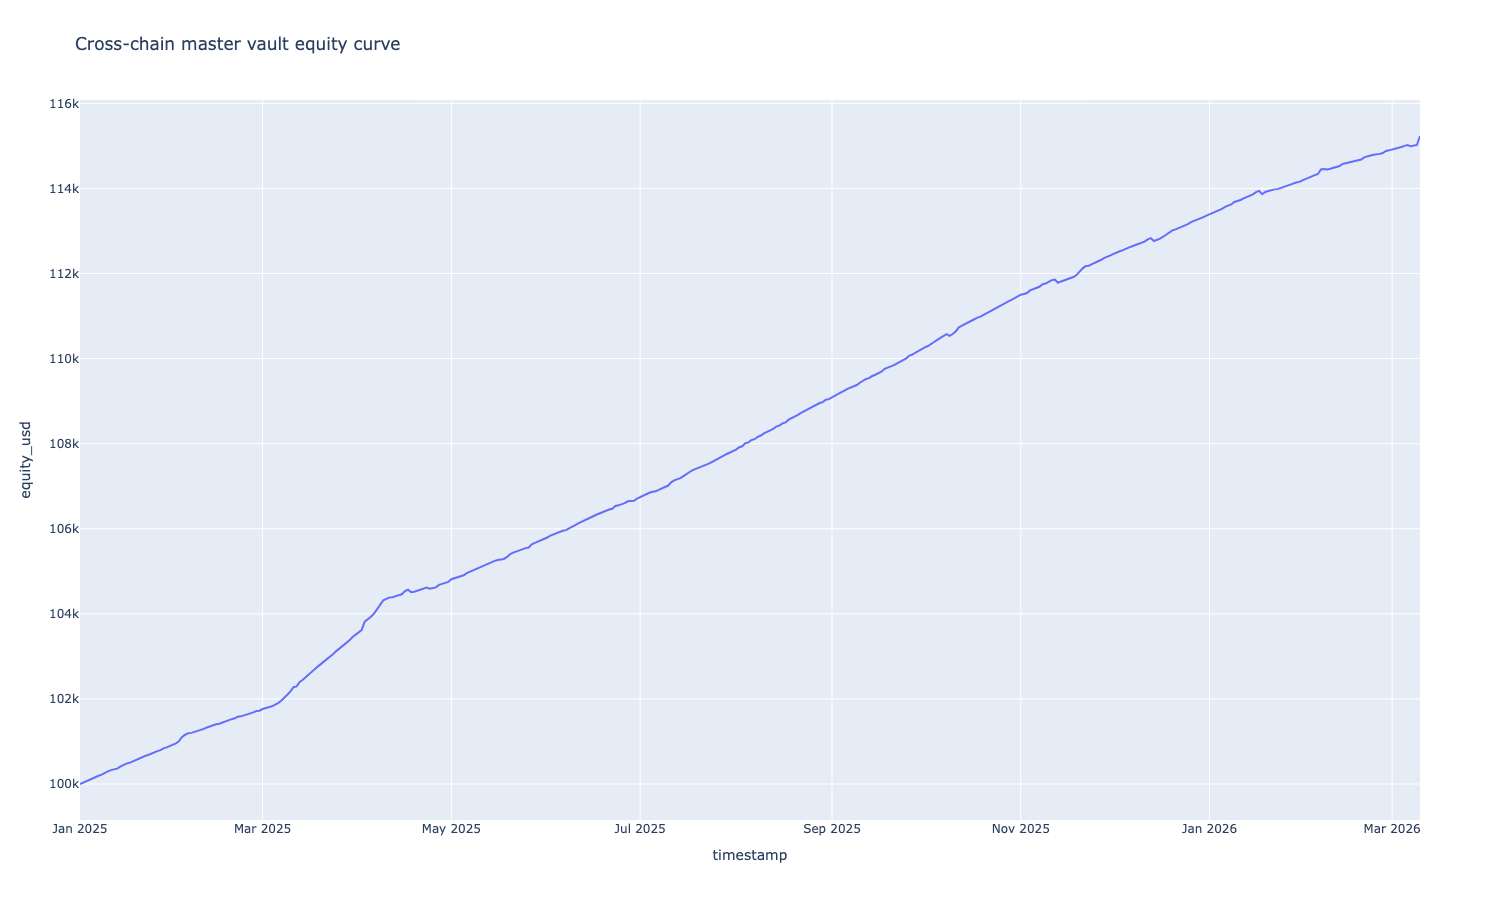

In [13]:
equity_df = equity_curve.rename("equity_usd").reset_index()
equity_df.columns = ["timestamp", "equity_usd"]
fig = px.line(equity_df, x="timestamp", y="equity_usd", title="Cross-chain master vault equity curve")
fig.show()


### Daily return distribution chart

Show the distribution of daily strategy returns to make outlier days and return skew easier to inspect.


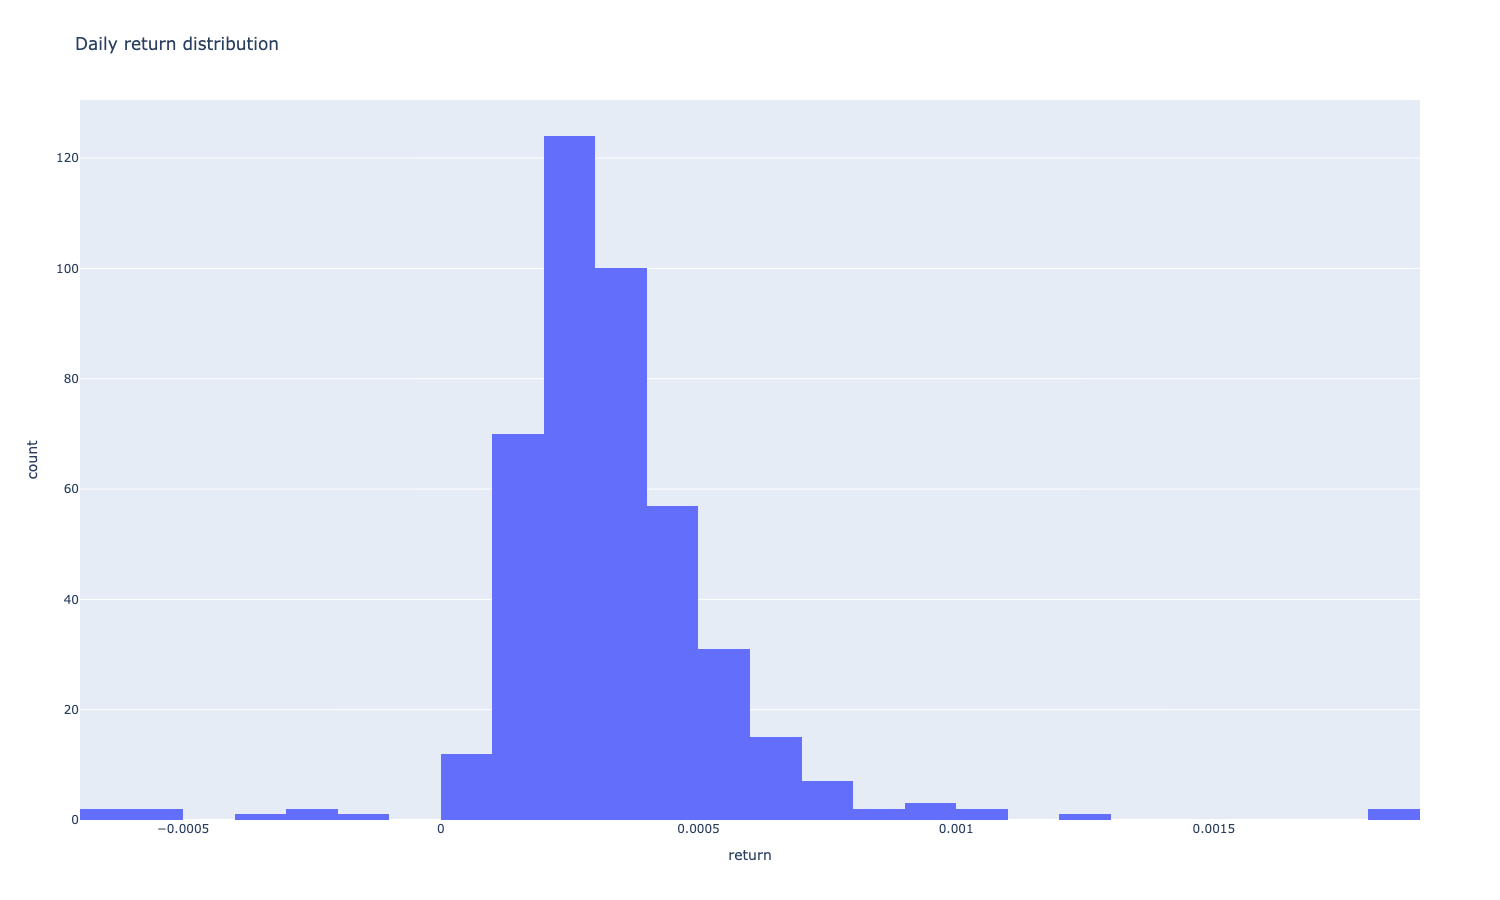

In [14]:
returns_df = returns.rename("return").reset_index()
returns_df.columns = ["timestamp", "return"]
fig = px.histogram(returns_df, x="return", nbins=50, title="Daily return distribution")
fig.show()


## Vault and chain diagnostics

Summarise final open exposure by chain and show the tail of the executed vault trades.


In [15]:
from tradeexecutor.analysis.position import build_chain_exposure_snapshot

positions_df, chain_exposure_df = build_chain_exposure_snapshot(
    state.portfolio.get_open_and_frozen_positions()
)
display(chain_exposure_df)
display_head_and_tail(positions_df, head_rows=10, tail_rows=5)

,chain_id,positions,value_usd,weight
0,1,1,4518.720077,0.040056
1,8453,5,67657.680394,0.599745
2,42161,3,40634.325532,0.360199


,position_id,chain_id,pair,value_usd,opened_at
2,4,8453,wsrarcV2USDC-USDC,13551.383923,2025-01-01
4,6,8453,gUSDC-USDC,13551.383923,2025-01-01
6,103,42161,HYPE++-USDC,13551.383923,2026-01-31
8,105,42161,plvHedge-USDC,13551.383923,2026-03-10
3,5,42161,gUSDC-USDC,13531.557686,2025-01-01
7,104,8453,fUSDC-USDC,13525.530130,2026-02-16
1,2,8453,srarcV2USDC-USDC,13522.145655,2025-01-01
5,92,8453,GUSDC-USDC,13507.236765,2025-12-05
0,1,1,MPL-aqUSDC1-USDC,4518.720077,2025-01-01


## Standard performance view

Render the standard chart registry from the production strategy for performance and allocation review.


### Chart renderer setup

Initialise the standard strategy chart renderer with the completed backtest state and indicator data.


In [16]:
from tradeexecutor.strategy.chart.renderer import ChartBacktestRenderingSetup

charts = create_charts(
    timestamp=None,
    parameters=parameters,
    strategy_universe=strategy_universe,
    execution_context=notebook_execution_context,
)
chart_renderer = ChartBacktestRenderingSetup(
    registry=charts,
    strategy_input_indicators=indicator_data,
    state=state,
    backtest_start_at=Parameters.backtest_start,
    backtest_end_at=Parameters.backtest_end,
)

### Performance metrics table

Summarise headline backtest performance metrics from the standard chart registry.


In [17]:
performance_metrics_df = chart_renderer.render(performance_metrics)
display(performance_metrics_df)


,Strategy,BTC,ETH
Start Period,2025-01-01,2025-01-01,2025-01-01
End Period,2026-03-10,2026-03-10,2026-03-10
Risk-Free Rate,0.0%,0.0%,0.0%
Time in Market,100.0%,100.0%,100.0%
Cumulative Return,15.23%,-26.28%,-39.27%
CAGR﹪,12.7%,-22.66%,-34.32%
Sharpe,27.71,-0.33,-0.17
Prob. Sharpe Ratio,100.0%,36.07%,42.61%
Smart Sharpe,21.45,-0.25,-0.13
Sortino,95.2,-0.46,-0.25


### Latest cycle snapshot

Cash, allocation, and redemption breakdown for the most recent strategy cycle.

In [18]:
snapshot_df = chart_renderer.render(latest_cycle_snapshot)
display(snapshot_df)

,Metric,Value
0,Final cycle,2026-03-10 00:00:00
1,Total equity USD,115232.86
2,Cash USD,2440.74
3,Cash % of equity,0.021181
4,Redeemable capital USD,NaN
5,Pending redemptions USD,NaN
6,Investable equity USD,NaN
7,Accepted investable equity USD,NaN
8,Accepted / investable %,NaN
9,Allocated to signals USD,NaN


### Asset weight chart

Visualise how portfolio allocation moved across vault assets during the backtest.


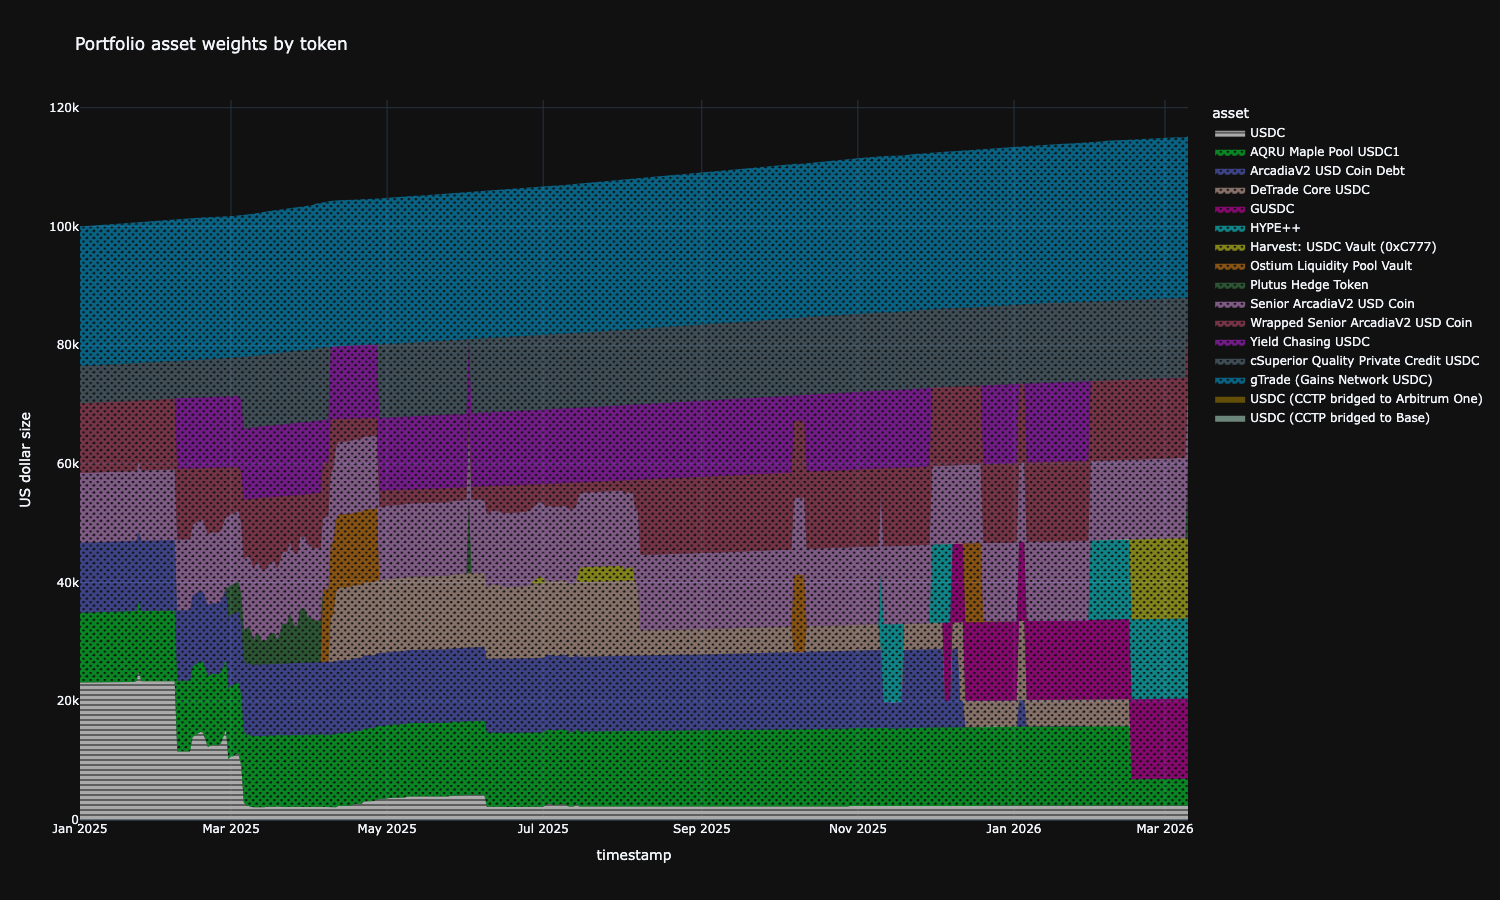

In [19]:
token_weights_fig = chart_renderer.render(equity_curve_by_asset)
token_weights_fig.update_layout(title="Portfolio asset weights by token")
token_weights_fig.show()


### Chain weight chart

Visualise cross-chain allocation between the primary chain and satellite chains, then show the underlying data sample.


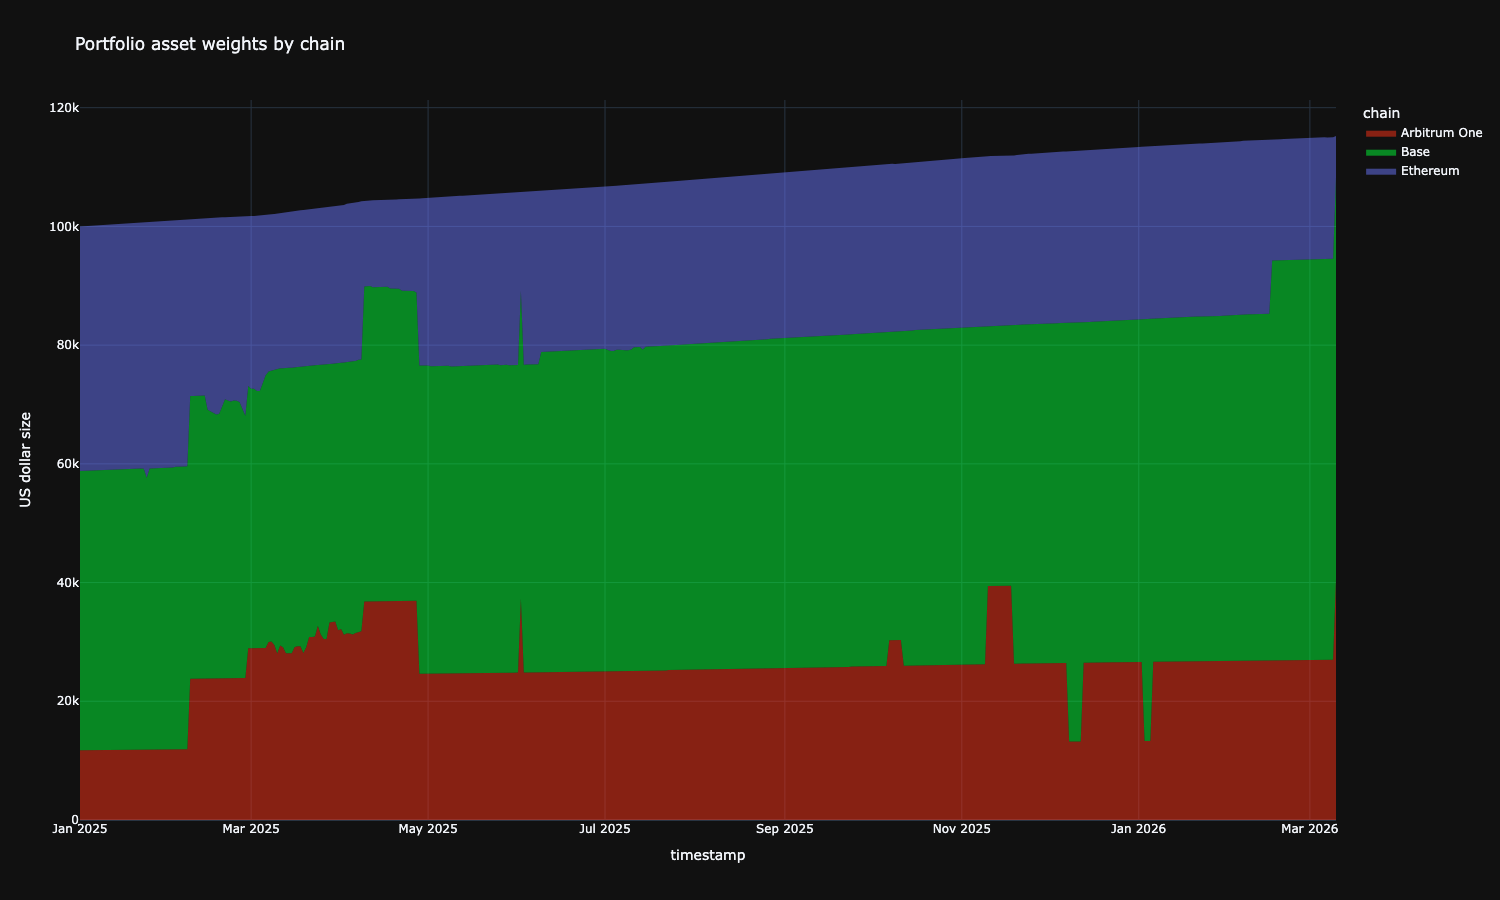

Head (10 rows)


chain,Arbitrum One,Base,Ethereum
timestamp,,,
2025-01-01,11760.000000,47040.000000,41200.000000
2025-01-02,11763.787133,47057.116815,41211.776649
2025-01-03,11769.581654,47081.494690,41220.211554
2025-01-04,11772.106409,47096.805727,41232.187807
2025-01-05,11774.486301,47124.804282,41232.187807
2025-01-06,11781.150000,47142.551131,41252.632236
2025-01-07,11783.850660,47157.769944,41252.632236
2025-01-08,11789.107118,47177.585761,41252.632236
2025-01-09,11796.681384,47194.267114,41273.034321


Tail (10 rows)


chain,Arbitrum One,Base,Ethereum
timestamp,,,
2026-03-01,26985.300582,67484.199330,20443.064061
2026-03-02,26988.012384,67491.207883,20451.653824
2026-03-03,26991.599983,67500.051254,20460.331057
2026-03-04,26997.266279,67509.955284,20469.008290
2026-03-05,27001.993468,67521.438316,20477.646415
2026-03-06,27003.850578,67530.956523,20486.943807
2026-03-07,27005.317273,67534.432777,20450.995927
2026-03-08,27006.277483,67539.562461,20459.343284
2026-03-09,27009.210873,67544.730489,20467.606418


In [20]:
chain_weights_fig, chain_weights_df = chart_renderer.render(equity_curve_by_chain)
chain_weights_fig.update_layout(title="Portfolio asset weights by chain")
chain_weights_fig.show()
display_head_and_tail(chain_weights_df, head_rows=10, tail_rows=10)


### Weight allocation statistics table

Summarise portfolio allocation behaviour across the backtest using the standard weight statistics table.


In [21]:
weight_allocation_statistics_df = chart_renderer.render(weight_allocation_statistics)
display(weight_allocation_statistics_df)


,At,Pair,Value,Address
Name,,,,
Max position (excluding USDC),2026-03-10,gTrade (Gains Network USDC),"$27,082.94",
Min position (excluding USDC),2025-06-27,Harvest: USDC Vault (0xC777),$574.74,
Mean position (excluding USDC),,,"$13,146.85",
Max position (excluding USDC),2025-01-24,gTrade (Gains Network USDC),31.25%,
Min position (excluding USDC),2025-06-27,Harvest: USDC Vault (0xC777),0.55%,
Mean position (excluding USDC),,,12.75%,
Max position (including USDC),2025-01-24,USDC,24.73%,
Min position (including USDC),2025-06-27,Harvest: USDC Vault (0xC777),0.54%,
Mean position (including USDC),,,11.31%,


### Trading pair breakdown table

Show the final trading-pair diagnostics with chain metadata to inspect which vaults and bridges participated in the run.


In [22]:
trading_pair_breakdown_df = chart_renderer.render(trading_pair_breakdown_with_chain)
display_head_and_tail(trading_pair_breakdown_df, head_rows=10, tail_rows=10)

,Trading pair,Chain,Address,Positions,Trades,Total return %,Total PnL USD,Best,Worst,Avg,Median,Volume,Wins,Losses,Take profits,Stop losses,Trailing stop losses,Volatility
11,cSuperior Quality Private Credit USDC,Ethereum,0x438982…,3,72,31.29%,"3,793.16",14.92%,1.60%,10.43%,14.76%,"76,873.28",3,0,0,0,0,6.24%
0,AQRU Maple Pool USDC1,Ethereum,0xe9d332…,1,37,18.85%,"2,236.49",18.85%,18.85%,18.85%,18.85%,"21,452.85",1,0,0,0,0,0.00%
4,gTrade (Gains Network USDC),Base,0xad2052…,1,13,13.70%,"1,654.28",13.70%,13.70%,13.70%,13.70%,"12,260.38",1,0,0,0,0,0.00%
3,gTrade (Gains Network USDC),Arbitrum One,0xd3443e…,1,14,12.54%,"1,521.64",12.54%,12.54%,12.54%,12.54%,"12,259.08",1,0,0,0,0,0.00%
1,Senior ArcadiaV2 USD Coin,Base,0xefe328…,1,10,10.58%,"1,293.37",10.58%,10.58%,10.58%,10.58%,"12,228.77",1,0,0,0,0,0.00%
13,DeTrade Core USDC,Base,0x8092ca…,4,35,6.50%,753.46,4.42%,0.39%,1.63%,0.85%,"89,385.68",4,0,0,0,0,1.62%
15,ArcadiaV2 USD Coin Debt,Base,0x3ec4a2…,2,19,4.69%,"1,362.15",4.59%,0.10%,2.35%,2.35%,"69,421.90",2,0,0,0,0,2.24%
14,Yield Chasing USDC,Arbitrum One,0x0df2e3…,3,22,3.65%,875.18,3.00%,0.21%,1.22%,0.43%,"106,743.50",3,0,0,0,0,1.27%
2,Wrapped Senior ArcadiaV2 USD Coin,Base,0xbc1071…,1,99,1.89%,"1,013.43",1.89%,1.89%,1.89%,1.89%,"94,875.79",1,0,0,0,0,0.00%
5,GUSDC,Base,0xd5c22f…,1,6,1.86%,248.05,1.86%,1.86%,1.86%,1.86%,"13,434.54",1,0,0,0,0,0.00%
